In [1]:
import pandas as pd

In [2]:
import os 
print(os.getcwd())
os.listdir("../data/clean/")

C:\Users\justi\zzzFORTHEFUTURE\second_project_starwars_etl\analysis


['.ipynb_checkpoints', 'df_people.csv', 'df_planets.csv', 'df_species.csv']

In [3]:
people = pd.read_csv("../data/clean/df_people.csv", dtype={
    "height": "Int64", "mass": "Int64", "id_homeworld": "Int64", "id_species": "Int64"})
planets = pd.read_csv("../data/clean/df_planets.csv", dtype={ 
    "rotation_period": "Int64", "orbital_period": "Int64", "diameter": "Int64", "population": "Int64", "id_people": "Int64"})
species = pd.read_csv("../data/clean/df_species.csv", dtype={
    "average_height": "Int64", "id_homeworld": "Int64", "id_people": "Int64"})

In [4]:
people["id"] = range(1, len(people) + 1)
planets["id"] = range(1, len(planets) + 1)
species["id"] = range(1, len(species) + 1)

In [5]:
people.head()

,name,height,mass,hair_color,skin_color,eye_color,birth_year,gender,id_homeworld,id_species,id
0,Luke Skywalker,172,77,blond,fair,blue,19BBY,male,1,<NA>,1
1,C-3PO,167,75,NaN,gold,yellow,112BBY,NaN,1,2,2
2,R2-D2,96,32,NaN,"white, blue",red,33BBY,NaN,8,2,3
3,Darth Vader,202,136,NaN,white,yellow,41.9BBY,male,1,<NA>,4
4,Leia Organa,150,49,brown,light,brown,19BBY,female,2,<NA>,5


In [6]:
planets.head()

,name,rotation_period,orbital_period,diameter,climate,gravity,terrain,population,id_people,id
0,Tatooine,23,304,10465,arid,1 standard,desert,200000,1,1
1,Alderaan,24,364,12500,temperate,1 standard,"grasslands, mountains",2000000000,5,2
2,Yavin IV,24,4818,10200,"temperate, tropical",1 standard,"jungle, rainforests",1000,<NA>,3
3,Hoth,23,549,7200,frozen,1.1 standard,"tundra, ice caves, mountain ranges",<NA>,<NA>,4
4,Dagobah,23,341,8900,murky,NaN,"swamp, jungles",<NA>,<NA>,5


In [7]:
species.head()

,name,classification,designation,average_height,skin_colors,eye_colors,id_homeworld,language,id_people,id
0,Human,mammal,sentient,180,"caucasian, black, asian, hispanic","brown, blue, green, hazel, grey, amber",9,Galactic Basic,66,1
1,Droid,artificial,sentient,<NA>,NaN,NaN,<NA>,NaN,2,2
2,Wookie,mammal,sentient,210,gray,"blue, green, yellow, brown, golden, red",14,Shyriiwook,13,3
3,Rodian,reptilian,sentient,170,"green, blue",black,23,Galatic Basic,15,4
4,Hutt,gastropod,sentient,300,"green, brown, tan","yellow, red",24,Huttese,16,5


In [8]:
# Number of poeple by gender
people.groupby('gender', dropna=False)['name'].count()

gender
female           17
hermaphrodite     1
male             60
NaN               4
Name: name, dtype: int64

In [9]:
# Average height and mass by gender 
people.groupby('gender', dropna=False)[['height', 'mass']].mean().round(2)

,height,mass
gender,,
female,166.65,104.6
hermaphrodite,175.0,1358.0
male,179.24,97.0
NaN,140.0,69.75


In [10]:
# mass info by gender with aggregation
people.groupby('gender', dropna=False).agg({
    "mass" : ["mean", "max", "min"]}) 

mass            
                 mean   max   min
gender                           
female          104.6   562    45
hermaphrodite  1358.0  1358  1358
male             97.0   782    15
NaN             69.75   140    32

In [11]:
# species ratio
species['classification'].value_counts()

classification
mammal        17
amphibian      6
reptilian      5
artificial     1
gastropod      1
insectoid      1
Name: count, dtype: int64

In [12]:
# planet that looks like Earth
earth = planets[(planets["rotation_period"].between(20,28)) &
    (planets["orbital_period"].between(300,400)) &
    (planets["diameter"].between(12500,13000))].min()
earth

name                            Alderaan
rotation_period                       24
orbital_period                       351
diameter                           12500
climate                        temperate
gravity                       1 standard
terrain            grasslands, mountains
population                      45000000
id_people                              5
id                                     2
dtype: object

In [55]:
# characters with their species
pd.merge(species, people, left_on="id", right_on="id_species").head(11)[['name_x','name_y']].sort_values('name_y')

,name_x,name_y
2,Human,Bail Prestor Organa
4,Droid,C-3PO
8,Wookie,Chewbacca
1,Human,Dooku
0,Human,Dormé
10,Rodian,Greedo
7,Droid,IG-88
3,Human,Jocasta Nu
5,Droid,R2-D2
6,Droid,R5-D4


In [14]:
df = pd.merge(species, people, left_on="id", right_on="id_species")
df = df.pivot_table(index = ["classification"], values= ["height", "mass"], 
                    aggfunc = {'max', 'min', 'mean'})
df.round(2)

height               mass              
                  max    mean  min   max    mean   min
classification                                        
amphibian         229  204.22  180   102   84.67    66
artificial        200   140.0   96   140   69.75    32
gastropod         175   175.0  175  1358  1358.0  1358
insectoid         183   183.0  183    80    80.0    80
mammal            264  174.79   66   562   96.06    17
reptilian         216   165.2   79   159    83.2    15

In [56]:
# Character by planet and species
pd.merge(pd.merge(people, planets, left_on='id_homeworld', right_on='id', suffixes=('', '_planets')), species, left_on='id_species', 
                  right_on='id', suffixes=('', '_classspecies'))[['name', 'name_planets', 'name_classspecies']].sort_values('name_classspecies')

,name,name_planets,name_classspecies
21,Ratts Tyerel,Aleen Minor,Aleena
40,Dexter Jettster,Ojom,Besalisk
25,Ki-Adi-Mundi,Cerea,Cerean
32,Mas Amedda,Champala,Chagrian
39,Zam Wesell,Zolan,Clawdite
0,C-3PO,Tatooine,Droid
1,R2-D2,Naboo,Droid
2,R5-D4,Tatooine,Droid
7,IG-88,NaN,Droid
17,Sebulba,Malastare,Dug


In [44]:
# Top 3 of nomber of character link to a planet
df = pd.merge(planets, people, left_on='id', right_on='id_homeworld', suffixes=('_planets', '_character'))[['name_planets', 'name_character']]
df.groupby("name_planets")["name_character"].count().sort_values(ascending=False)[:3]

name_planets
Naboo       11
Tatooine    10
Alderaan     3
Name: name_character, dtype: int64

In [53]:
# Correlation between heigh and mass
people[['height', 'mass']].corr()

,height,mass
height,1.000000,0.120201
mass,0.120201,1.000000


In [57]:
import matplotlib.pyplot as plt

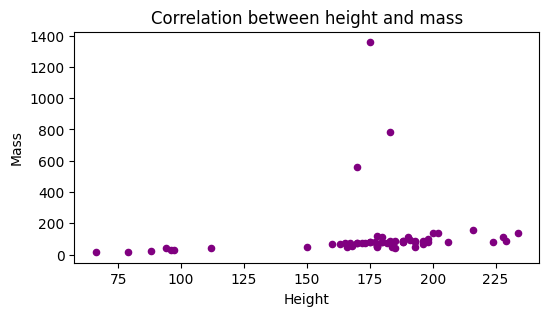

In [70]:
ax = people.plot(kind='scatter', x='height', y='mass', color='purple', title='Correlation between height and mass', figsize=(6,3))
ax.set_xlabel('Height')
ax.set_ylabel('Mass')
plt.show()

In [87]:
df = pd.merge(species, planets, left_on='id_homeworld', right_on='id')

In [88]:
top = df.sort_values(by='population', ascending=False).head(5)
top

,name_x,classification,designation,average_height,skin_colors,eye_colors,id_homeworld,language,id_people_x,id_x,name_y,rotation_period,orbital_period,diameter,climate,gravity,terrain,population,id_people_y,id_y
0,Human,mammal,sentient,180,"caucasian, black, asian, hispanic","brown, blue, green, hazel, grey, amber",9,Galactic Basic,66,1,Coruscant,24,368,12240,temperate,1 standard,"cityscape, mountains",1000000000000,34,9
31,Skakoan,mammal,sentient,<NA>,"grey, green",NaN,56,Skakoan,76,33,Skako,27,384,<NA>,temperate,1,"urban, vines",500000000000,76,56
26,Geonosian,insectoid,sentient,178,"green, brown","green, hazel",11,Geonosian,63,28,Geonosis,30,256,11370,"temperate, arid",0.9 standard,"rock, desert, mountain, barren",100000000000,63,11
6,Mon Calamari,amphibian,sentient,160,"red, blue, brown, magenta",yellow,31,Mon Calamarian,27,8,Mon Cala,21,398,11030,temperate,1,"oceans, reefs, islands",27000000000,27,31
8,Sullustan,mammal,sentient,180,pale,black,33,Sullutese,31,10,Sullust,20,263,12780,superheated,1,"mountains, volcanoes, rocky deserts",18500000000,31,33


In [89]:
other = df.sort_values(by='population', ascending=False).iloc[5:]
other_sum = other['population'].sum()

In [90]:
top = pd.concat([top, pd.DataFrame([{'name_x':'Other', 'population': other_sum}])])
top

,name_x,classification,designation,average_height,skin_colors,eye_colors,id_homeworld,language,id_people_x,id_x,name_y,rotation_period,orbital_period,diameter,climate,gravity,terrain,population,id_people_y,id_y
0,Human,mammal,sentient,180,"caucasian, black, asian, hispanic","brown, blue, green, hazel, grey, amber",9,Galactic Basic,66,1.0,Coruscant,24,368,12240,temperate,1 standard,"cityscape, mountains",1000000000000,34,9.0
31,Skakoan,mammal,sentient,<NA>,"grey, green",NaN,56,Skakoan,76,33.0,Skako,27,384,<NA>,temperate,1,"urban, vines",500000000000,76,56.0
26,Geonosian,insectoid,sentient,178,"green, brown","green, hazel",11,Geonosian,63,28.0,Geonosis,30,256,11370,"temperate, arid",0.9 standard,"rock, desert, mountain, barren",100000000000,63,11.0
6,Mon Calamari,amphibian,sentient,160,"red, blue, brown, magenta",yellow,31,Mon Calamarian,27,8.0,Mon Cala,21,398,11030,temperate,1,"oceans, reefs, islands",27000000000,27,31.0
8,Sullustan,mammal,sentient,180,pale,black,33,Sullutese,31,10.0,Sullust,20,263,12780,superheated,1,"mountains, volcanoes, rocky deserts",18500000000,31,33.0
0,Other,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,31904000000,<NA>,NaN


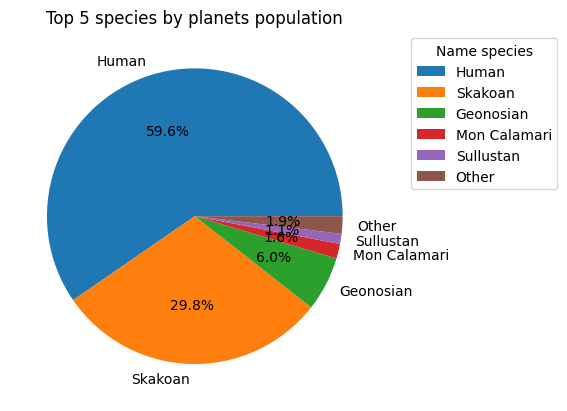

In [97]:
ax = top['population'].plot(kind='pie', autopct='%1.1f%%', labels=top['name_x'], title='Top 5 species by planets population')
ax.legend(top['name_x'],
          title="Name species",
          loc="upper right",
          bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()